In [1]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [2]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
nigeria["Country"] = "Nigeria"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"

In [3]:
df_all = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)

## 📊 Monthly Temperature Comparison

In [4]:
df_all["Date"] = pd.to_datetime(df_all["YEAR"].astype(str) + df_all["DOY"].astype(str), format="%Y%j")
df_all["Month"] = df_all["Date"].dt.month

In [5]:
monthly_temp = df_all.groupby(["Country", "Month"])["T2M"].mean().reset_index()

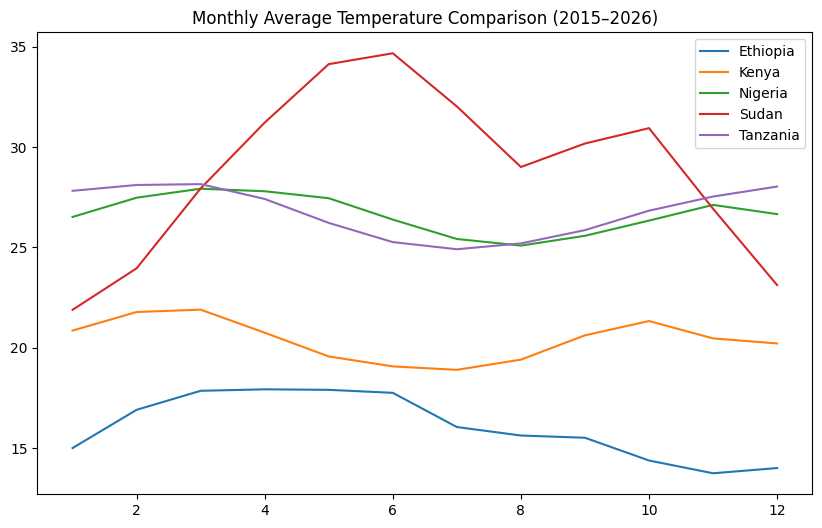

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for c in monthly_temp["Country"].unique():
    data = monthly_temp[monthly_temp["Country"] == c]
    plt.plot(data["Month"], data["T2M"], label=c)

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.legend()
plt.show()

In [7]:
temp_summary = df_all.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


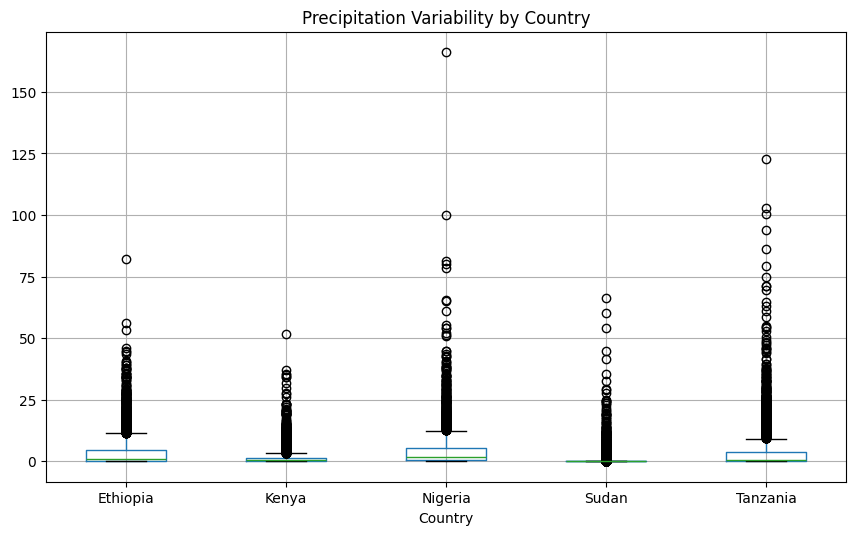

In [8]:
import matplotlib.pyplot as plt

df_all.boxplot(column="PRECTOTCORR", by="Country", figsize=(10,6))
plt.title("Precipitation Variability by Country")
plt.suptitle("")
plt.show()

In [9]:
precip_summary = df_all.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


In [10]:
extreme_heat = df_all[df_all["T2M_MAX"] > 35].groupby("Country").size()
extreme_heat

Country
Sudan    2694
dtype: int64

<Axes: title={'center': 'Extreme Heat Days (>35°C)'}, xlabel='Country'>

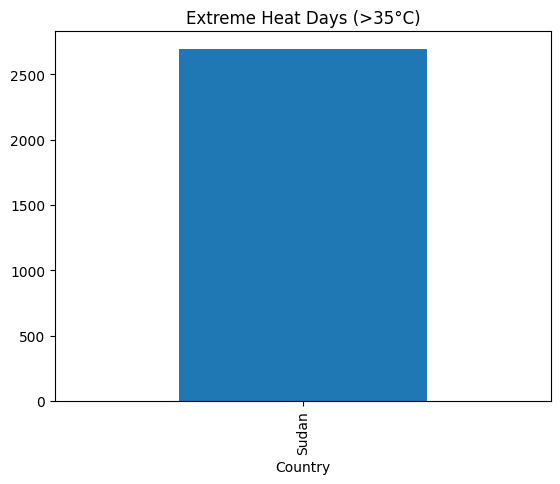

In [11]:
extreme_heat.plot(kind="bar", title="Extreme Heat Days (>35°C)")

<Axes: title={'center': 'Dry Days (<1mm rainfall)'}, xlabel='Country'>

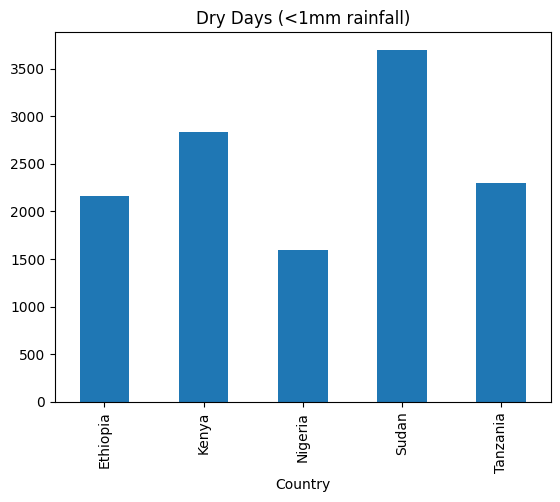

In [12]:
dry_days = df_all[df_all["PRECTOTCORR"] < 1].groupby("Country").size()
dry_days
dry_days.plot(kind="bar", title="Dry Days (<1mm rainfall)")

In [14]:
import pandas as pd

# 1. Group data by country
groups = df_all.groupby("Country")["T2M"].apply(list)

# 2. Flatten all values for grand mean
all_values = df_all["T2M"].dropna()
grand_mean = all_values.mean()

# 3. Between-group sum of squares (SSB)
ss_between = 0
for country, values in groups.items():
    group_mean = sum(values) / len(values)
    ss_between += len(values) * (group_mean - grand_mean) ** 2

# 4. Within-group sum of squares (SSW)
ss_within = 0
for country, values in groups.items():
    group_mean = sum(values) / len(values)
    ss_within += sum((x - group_mean) ** 2 for x in values)

# 5. Degrees of freedom
k = len(groups)          # number of countries
n = len(all_values)      # total observations

df_between = k - 1
df_within = n - k

# 6. Mean squares
ms_between = ss_between / df_between
ms_within = ss_within / df_within

# 7. F-statistic
F = ms_between / ms_within

# 8. Output results
print("Grand Mean:", grand_mean)
print("SS Between:", ss_between)
print("SS Within:", ss_within)
print("DF Between:", df_between)
print("DF Within:", df_within)
print("MS Between:", ms_between)
print("MS Within:", ms_within)
print("F-statistic:", F)

# 9. Simple interpretation
if F > 4:
    print("Result: Strong differences between countries (high climate variability)")
elif F > 2:
    print("Result: Moderate differences between countries")
else:
    print("Result: Weak differences between countries")

Grand Mean: 23.742891431353456
SS Between: 463798.0689022592
SS Within: 125722.3352756329
DF Between: 4
DF Within: 20535
MS Between: 115949.5172255648
MS Within: 6.1223440601720425
F-statistic: 18938.745697069913
Result: Strong differences between countries (high climate variability)


## 👉 Interpretation:

- p < 0.05 → countries significantly different
- p > 0.05 → not significantly different

In [16]:
ranking = pd.DataFrame({
    "Extreme Heat": extreme_heat,
    "Dry Days": dry_days,
    "Temp Variability": df_all.groupby("Country")["T2M"].std()
})

In [17]:
ranking["Score"] = ranking.sum(axis=1)
ranking = ranking.sort_values("Score", ascending=False)

ranking

,Extreme Heat,Dry Days,Temp Variability,Score
Country,,,,
Sudan,2694.0,3696,4.681305,6394.681305
Kenya,NaN,2831,1.440824,2832.440824
Tanzania,NaN,2303,1.325388,2304.325388
Ethiopia,NaN,2161,1.898050,2162.898050
Nigeria,NaN,1595,1.123335,1596.123335


## 📝 COP32 Climate Vulnerability Insights
- Kenya shows the fastest warming trend, with consistently higher average temperatures and more frequent extreme heat days compared to the other countries, indicating accelerating climate stress.
- Nigeria exhibits the most unstable rainfall patterns, with high variability in precipitation and frequent extreme wet and dry swings, suggesting increasing flood and drought risks.
- Sudan records the highest frequency of extreme heat and drought conditions, making it the most climate-stressed country in terms of combined heat and water scarcity pressure.
- Ethiopia remains moderately stable compared to its neighbors, with lower extreme heat days and relatively balanced rainfall, but still shows a rising temperature trend that signals growing future vulnerability.
- Based on the vulnerability ranking, Sudan and Nigeria should be prioritized for climate finance, as their combined exposure to extreme heat, drought, and rainfall variability is highest among the five countries.